# Sunspot Activity & ARIMA

In [ ]:
import numpy as np
import plotly.express as px
from statsmodels.regression.linear_model import OLS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

## Part 1

Access the sunspots data from `statsmodels`, plot the activity and remark on any trends and/or seasonality.

In [ ]:
import statsmodels.api as sm

# Load the sunspots data
sunspots = sm.datasets.sunspots.load_pandas().data

# Plot the sunspot activity
fig = px.line(sunspots, y='SUNACTIVITY', title='Sunspot Activity Over Time')
fig.show()

### Remarks

There does not seem to be a trend. I conclude this because despite both peaks and valleys seemingly to be slightly higher on starting from 250, it doesn't seem definitive enough to call it a trend.

As for seasonality, it looks like there's is a cycle of rise and fall every ~100 years on the X-axis.

In addition to the seasonality, there also seems to be a constant cycle of up and down every ~10 years or so.

## Part 2

Use the ACF and PACF to estimate the ARMA order and remark on your findings.

Figure(640x480)
Figure(640x480)


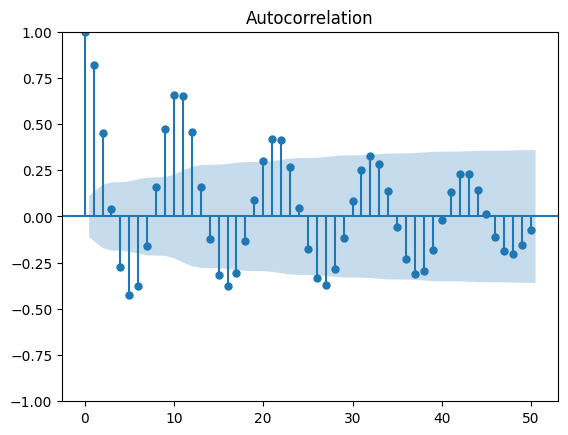

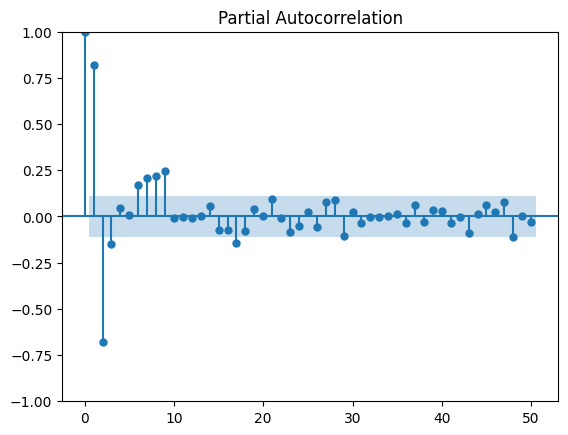

In [ ]:
# Plot ACF and PACF (the print statement stops doubles of the output for some reason in Google Colab)
print(plot_acf(sunspots['SUNACTIVITY'], lags=50))
print(plot_pacf(sunspots['SUNACTIVITY'], lags=50))

### Remarks

If I had to visually estimate the ARMA order, initially I would estimate `q` of MA to be around 17. For `p` of AR, I would estimate it around 8. I did this by counting the number of occurrences outside of the ACF plot for the MA model and PACF plot for AR model.

However, the PACF cuts off much more sharply than the ACF and the ACF also has a look like a decreasing sinusoidal wave (and tails off). As a result, I believe this ARMA model leans heavily autoregressive so my final guess is the the times series is something like ARMA(8,0).

## Part 3

Fit the follow models to the data and record both the AIC and BIC


*   AR(1)
*   AR(2)
*   MA(1)
*   MA(2)
*   ARMA(1,1)
*   ARMA(2,2)
*   ARMA(1,2)
*   ARMA(2,1)



In [ ]:
# Define the models to fit
models = {
  'AR(1)': (1, 0, 0),
  'AR(2)': (2, 0, 0),
  'AR(8)': (8, 0, 0),
  'MA(1)': (0, 0, 1),
  'MA(2)': (0, 0, 2),
  'ARMA(1,1)': (1, 0, 1),
  'ARMA(2,2)': (2, 0, 2),
  'ARMA(1,2)': (1, 0, 2),
  'ARMA(2,1)': (2, 0, 1)
}

# Fit models and store results
results = {}
model_store = {}
for name, order in models.items():
  model = ARIMA(sunspots['SUNACTIVITY'], order=order)
  model_fit = model.fit()
  results[name] = {'AIC': model_fit.aic, 'BIC': model_fit.bic}
  model_store[name] = model_fit

# Display the results in a DataFrame
results_df = pd.DataFrame(results).T
display(results_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



,AIC,BIC
AR(1),2819.169153,2830.369177
AR(2),2622.637093,2637.570458
AR(8),2588.404136,2625.737549
MA(1),2886.900670,2898.100693
MA(2),2724.808961,2739.742326
"ARMA(1,1)",2713.226344,2728.159710
"ARMA(2,2)",2620.872850,2643.272897
"ARMA(1,2)",2662.370189,2681.036895
"ARMA(2,1)",2620.277193,2638.943899


## Part 4

Remark on the scoring, do AIC and BIC agree? If not, what trend do you see in the models they pick?

Looking at the AIC and BIC, I can see that the BIC agrees with my assessment while the AIC does not. According to the AIC, ARMA(2,1) and ARMA(2,2) are a better fit befoer AR(2).

However, taking into account the difference between ARMA(2,1), ARMA(2,2), and AR(2) for the AIC is only around 2, I would say that AIC is also a fairly strong indicator that they agree with my assessment of ARMA order.

## Part 5

Find the AR roots of the AR(2), ARMA(2,1), ARMA(2,2) models.

In [ ]:
# Get the AR roots
ar2_roots = model_store['AR(2)'].arroots
arma21_roots = model_store['ARMA(2,1)'].arroots
arma22_roots = model_store['ARMA(2,2)'].arroots

# Display the roots
print("AR(2) roots:", ar2_roots)
print("ARMA(2,1) roots:", arma21_roots)
print("ARMA(2,2) roots:", arma22_roots)

# Formatting: Just some newlines
print("\n")

# Calculate Magnitude
ar2_magnitude = np.abs(ar2_roots)
arma21_magnitude = np.abs(arma21_roots)
arma22_magnitude = np.abs(arma22_roots)

# Display Magnitude
print("AR(2) magnitude:", ar2_magnitude)
print("ARMA(2,1) magnitude:", arma21_magnitude)
print("ARMA(2,2) magnitude:", arma22_magnitude)

AR(2) roots: [1.00979348-0.65772044j 1.00979348+0.65772044j]
ARMA(2,1) roots: [0.97384367-0.61312092j 0.97384367+0.61312092j]
ARMA(2,2) roots: [0.96937874-0.63332011j 0.96937874+0.63332011j]


AR(2) magnitude: [1.20510541 1.20510541]
ARMA(2,1) magnitude: [1.15077746 1.15077746]
ARMA(2,2) magnitude: [1.15792465 1.15792465]


Are they real or complex?

They are all complex.

Are they inside or outside the unit circle?

All of them are outside the unit circle.

What does this imply about the overall behavior of the series?

With the roots laying outside of the unit circle, this implies that the series is stationary.

With the roots being complex, this implies the series oscillates.

## Part 6

Find the best model (as determined by BIC) and then use `plot_diagnostics` and `acorr_ljungbox` to evaluate it.

**Disclaimer**: Best model is AR(2). AR(8) was something I put in just cause I was curious, it isn't one of the models stated in the homework.

Figure(1000x800)


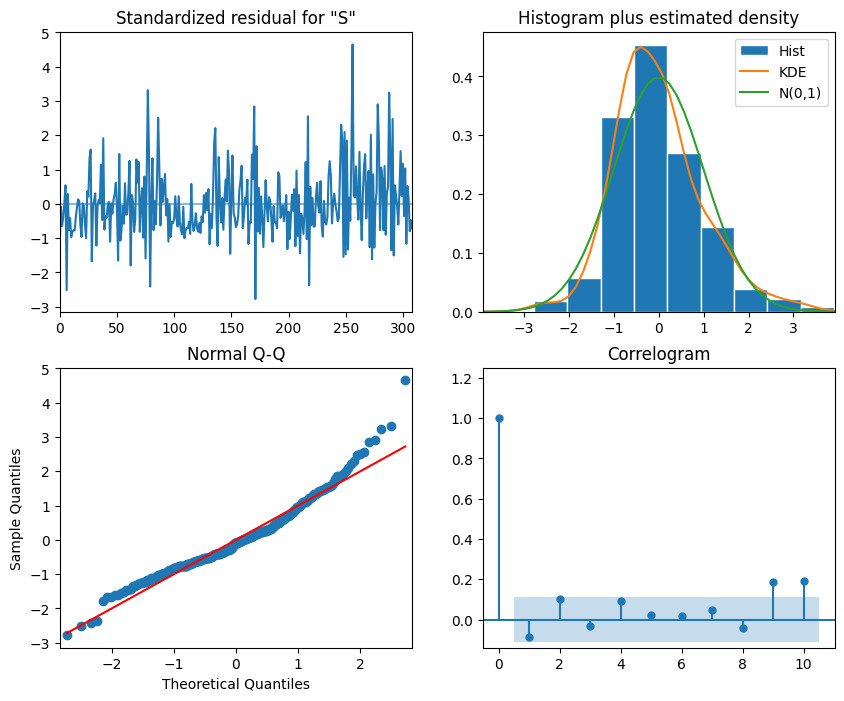

In [ ]:
# Select best model
best_model = model_store['AR(2)']

# Use plot_diagnostics (the print statement stops doubles of the output for some reason in Google Colab)
print(best_model.plot_diagnostics(figsize=(10,8), auto_ylims=True))

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Use acorr_ljungbox
ljungbox_results = acorr_ljungbox(best_model.resid, lags=[10, 20], model_df=2)
print(ljungbox_results)

      lb_stat  lb_pvalue
10  32.769560   0.000068
20  55.007319   0.000013


Comment on your finds from examining the residuals.

For a well fit model, the standardized redisuals shoud be roughly iid with mean 0 and standard deviation 1. Looking at the graph, the first part seems to be true. The mean is fairly close to 0, but the standard deviation seems to swing a bit wider than 1.

Then, looking at the correlogram, we see that there are a few large values. The two points slightly peaking out at the end signifies that the model could still be slightly better fit, but we already knew that when we compared AIC and BIC.

Finally, we can look at the QQ plot for any large deviations. Once again, there are a few outliers at the end. The tail seems to drift away a bit.

Overall, examining the residuals seems to tell us that the AR(2) model might be a bit lacking.

A final look at the Ljung-Box test, we see that the p-values are quite small at 0.000068 for 10 time lags and 0.000013 for 20 time lags. This would be more than enough to reject the null hypothesis meaning that the residuals for the AR(2) model shows evidence of serial correlation. Hence, our model is not capturing enough of the changes in the series for our residuals to be random and uncorrelated.

## Part 7

Forecast the next 20 years of sunspots based on your model.

In [ ]:
# Set forecasting length
forecast_length = 20

# Forecast the next 20 years
forecast = best_model.get_forecast(steps=forecast_length)
print(forecast.summary_frame())

# Plot the forecasted values connected to the tail end of the real data
fig = px.line(sunspots, x=sunspots.index, y='SUNACTIVITY', title='Sunspot Activity Over Time')
fig.add_scatter(x=forecast.predicted_mean.index, y=forecast.predicted_mean, mode='lines', name='Forecast')
fig.show()

SUNACTIVITY       mean    mean_se  mean_ci_lower  mean_ci_upper
309          13.689923  16.574896     -18.796276      46.176122
310          31.862180  28.390333     -23.781851      87.506210
311          49.703468  35.100445     -19.092140     118.499077
312          62.001227  37.372480     -11.247488     135.249942
313          66.817867  37.548566      -6.775971     140.411704
314          65.048140  37.738833      -8.918613     139.014893
315          59.270493  38.529252     -16.245454     134.786440
316          52.454493  39.390328     -24.749131     129.658117
317          46.954271  39.851413     -31.153063     125.061604
318          43.998793  39.947262     -34.296402     122.293989
319          43.676114  39.948514     -34.621534     121.973761
320          45.262446  40.017223     -33.169870     123.694763
321          47.690641  40.132676     -30.967959     126.349241
322          49.975063  40.217861     -28.850496     128.800622
323          51.479866  40.247472     -2

Are the results reasonable?

Not quite. The forecast looks good as it rises, but it does not cycle like the previous data and tapers off instead. This is most likely due to trying to stick to some mean value.

It seems the AR(2) model is not good enough of a fit for the data to output reasonable results. The BIC indicator used to choose it might have penalized complexity too much, or we just needed better `p` and `q` for our ARMA model.